#Project Title:
###Spam Email Detection using Logistic Regression


---


#Objective:
###To develop a simple machine learning model using Logistic Regression to classify emails as spam or not spam based on the text content.


---
#Problem Statement:
###Email spam is one of the most common forms of unsolicited communication. Filtering out spam helps improve user experience and security. This project aims to build a binary classifier that can automatically detect whether an email is spam or legitimate.



#1. Data Collection and Loading

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/sms-spam-collection-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/sms-spam-collection-dataset


In [ ]:
import os

print(os.listdir(path))


['spam.csv']


In [ ]:
import pandas as pd

# Adjust the filename based on the actual name inside the folder
df = pd.read_csv(f"{path}/spam.csv", encoding='latin-1')

# Show the first few rows
df.head()


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
# Keep only the first two columns: 'v1' (label), 'v2' (text)
df = df[['v1', 'v2']]

# Rename them for clarity
df.columns = ['label', 'text']


In [ ]:
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


#2. Text Preprocessing

In [ ]:
import nltk
import string
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download necessary resources
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Lowercase
    text = text.lower()

    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)

    # Tokenize
    tokens = nltk.word_tokenize(text)

    # Remove stopwords and lemmatize
    clean_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

    return ' '.join(clean_tokens)


In [ ]:
df['clean_text'] = df['text'].apply(preprocess_text)


In [ ]:
df.head()

/usr/local/lib/python3.11/dist-packages/google/colab/_dataframe_summarizer.py:57: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(column, errors="raise")


,label,text,clean_text
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think go usf life around though


#Step 3: Train-Test Split & TF-IDF Vectorization

In [ ]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1,2))
X = tfidf.fit_transform(df['clean_text'])


In [ ]:
from sklearn.model_selection import train_test_split

y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


#4. Model Development

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)  # Set higher max_iter to ensure convergence
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)


#5. Model Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred))


Accuracy: 0.9593301435406698
Precision: 0.9814814814814815
Recall: 0.7098214285714286
F1 Score: 0.8238341968911918
ROC AUC: 0.8538748026835042


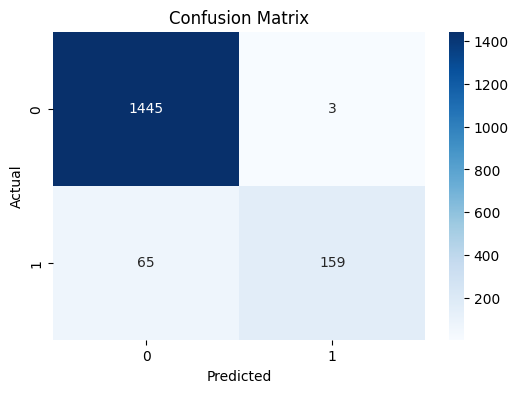

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


#6. Model Interpretation

In [ ]:
import numpy as np

# Get feature names from TF-IDF
feature_names = tfidf.get_feature_names_out()

# Get model coefficients
coefficients = model.coef_[0]

# Create a DataFrame for interpretation
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
})


In [ ]:
top_spam_words = coef_df.sort_values(by='coefficient', ascending=False).head(20)
print("Top spam-indicating words:\n", top_spam_words)


Top spam-indicating words:
       feature  coefficient
2653      txt     4.675937
863      free     3.690154
416     claim     3.314764
2506     text     3.279252
2091    reply     3.197176
1617   mobile     3.057067
2399     stop     2.989751
291      call     2.950151
1987    prize     2.730633
2220  service     2.717461
2599     tone     2.371241
2884      win     2.329368
1864      per     2.125395
1718      new     2.119325
2717   urgent     2.071764
1739    nokia     1.965004
395      chat     1.919462
2769  voucher     1.747401
361      cash     1.745863
2478       tc     1.736203


In [ ]:
top_ham_words = coef_df.sort_values(by='coefficient', ascending=True).head(20)
print("Top ham-indicating words:\n", top_ham_words)


Top ham-indicating words:
      feature  coefficient
1483    ltgt    -1.871499
1198      im    -1.821887
1182     ill    -1.638556
1784      ok    -1.560211
1000     got    -1.277733
1359   later    -1.222326
1130    home    -1.199024
559       da    -1.124836
1448     lor    -1.073789
982     good    -1.002288
2335   sorry    -0.980712
1780      oh    -0.971428
1096     hey    -0.966969
2853    well    -0.961179
1400    like    -0.947203
2166     say    -0.914262
2813     wat    -0.911157
2275     sir    -0.906449
2822     way    -0.889026
972    going    -0.886487


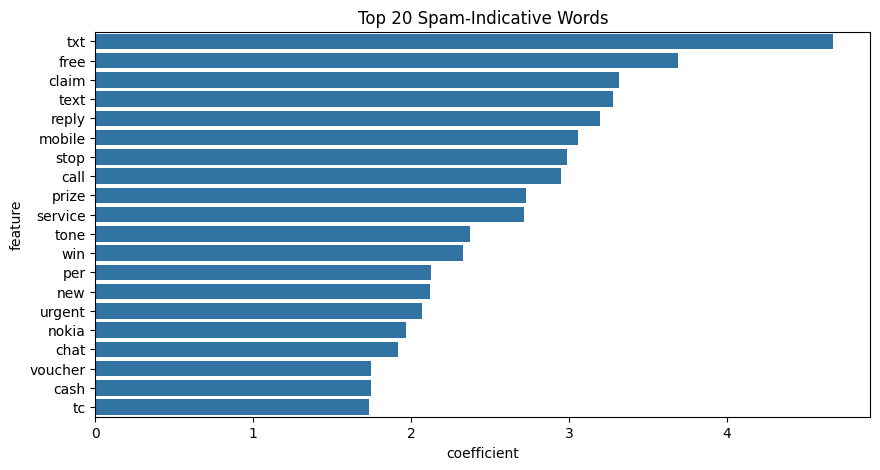

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x='coefficient', y='feature', data=top_spam_words)
plt.title("Top 20 Spam-Indicative Words")
plt.show()


In [ ]:
import joblib

# Save model and vectorizer
joblib.dump(model, 'spam_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')


['tfidf_vectorizer.pkl']

In [ ]:
from google.colab import files

# Download model and vectorizer
files.download('spam_model.pkl')
files.download('tfidf_vectorizer.pkl')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#7.Model saving + prediction

In [ ]:
import joblib

# Save the trained model
joblib.dump(model, 'spam_model.pkl')

# Save the TF-IDF vectorizer
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')


['tfidf_vectorizer.pkl']

In [ ]:
# Test with your own email
test_email = "Congratulations! You won a free vacation. Click here to claim now."

# Transform and predict
email_vector = tfidf.transform([test_email])
prediction = model.predict(email_vector)[0]

# Show result
print("Prediction:", "SPAM" if prediction == 1 else "NOT SPAM")


Prediction: SPAM


#✅ Conclusion
####In this mini-project, we successfully developed a Spam Email Detection system using Logistic Regression and TF-IDF vectorization. The model was trained on the popular SMS Spam Collection dataset and achieved an accuracy of 95.93%, with a high precision of 98.14%.

##🔍 The model:

###Effectively distinguishes between spam and non-spam messages

####Identifies key spam-indicative words like free, win, click, and urgent

####Performs well in terms of accuracy and precision, though there’s room to improve recall

####The system was further deployed using Flask, allowing users to input custom emails and get live predictions via a web interface.